In [2]:
# =========================================================
# Exploratory Data Analysis (EDA) With Python and Pandas
# USING PROVIDED DATASET: supermarket_sales.csv
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calmap

from ydata_profiling import ProfileReport

# Style Settings
plt.style.use('ggplot')
sns.set(font_scale=1.1)

# =========================================================
# LOAD DATASET
# =========================================================

# Load the uploaded dataset
df = pd.read_csv('supermarket_sales.csv')

# =========================================================
# BASIC DATA EXPLORATION
# =========================================================

print("First 5 Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# DATA PREPROCESSING
# =========================================================

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert Time column to datetime
df['Time'] = pd.to_datetime(df['Time'])

# Create additional useful columns
df['Month'] = df['Date'].dt.month_name()

df['Day'] = df['Date'].dt.day_name()

df['Hour'] = df['Time'].dt.hour

# =========================================================
# TASK 1: INITIAL DATA EXPLORATION
# =========================================================

print("\nUnique Cities:")
print(df['City'].unique())

print("\nUnique Branches:")
print(df['Branch'].unique())

print("\nCustomer Types:")
print(df['Customer type'].value_counts())

print("\nGender Distribution:")
print(df['Gender'].value_counts())

print("\nPayment Methods:")
print(df['Payment'].value_counts())

print("\nProduct Lines:")
print(df['Product line'].value_counts())

# =========================================================
# TASK 2: UNIVARIATE ANALYSIS
# =========================================================

# ---------------------------------------------------------
# Question 1:
# Distribution of Customer Ratings
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.histplot(df['Rating'],
             bins=20,
             kde=True)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

# Boxplot of Ratings

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Rating'])

plt.title('Boxplot of Customer Ratings')

plt.show()

# Check skewness

print("\nSkewness of Ratings:")
print(df['Rating'].skew())

# ---------------------------------------------------------
# Question 2:
# Aggregate Sales by Branch
# ---------------------------------------------------------

branch_sales = df.groupby('Branch')['Total'].sum()

print("\nTotal Sales by Branch:")
print(branch_sales)

plt.figure(figsize=(8,5))

sns.barplot(x=branch_sales.index,
            y=branch_sales.values)

plt.title('Aggregate Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')

plt.show()

# =========================================================
# TASK 3: BIVARIATE ANALYSIS
# =========================================================

# ---------------------------------------------------------
# Question 3:
# Relationship between Gross Income and Ratings
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(x='gross income',
                y='Rating',
                data=df)

plt.title('Gross Income vs Customer Rating')
plt.xlabel('Gross Income')
plt.ylabel('Rating')

plt.show()

# Correlation between gross income and rating

correlation = df['gross income'].corr(df['Rating'])

print("\nCorrelation between Gross Income and Rating:")
print(correlation)

# ---------------------------------------------------------
# Question 4:
# Time Trend in Gross Income
# ---------------------------------------------------------

gross_income_trend = df.groupby('Date')['gross income'].sum()

plt.figure(figsize=(14,6))

gross_income_trend.plot()

plt.title('Time Trend of Gross Income')
plt.xlabel('Date')
plt.ylabel('Gross Income')

plt.show()

# =========================================================
# CALENDAR HEATMAP USING CALMAP
# =========================================================

daily_income = df.groupby('Date')['gross income'].sum()

calmap.calendarplot(daily_income,
                    how='sum',
                    cmap='YlGn',
                    figsize=(16,8))

plt.show()

# =========================================================
# TASK 4: DEALING WITH DUPLICATES
# =========================================================

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

# =========================================================
# TASK 4: DEALING WITH MISSING VALUES
# =========================================================

print("\nMissing Values Before Treatment:")
print(df.isnull().sum())

# Fill numerical missing values with mean
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Treatment:")
print(df.isnull().sum())

# =========================================================
# TASK 5: CORRELATION ANALYSIS
# =========================================================

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation Matrix
corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

# =========================================================
# EXTRA VISUALIZATIONS
# =========================================================

# ---------------------------------------------------------
# Sales by Product Line
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

sns.barplot(x='Product line',
            y='Total',
            data=df,
            estimator=sum)

plt.xticks(rotation=45)

plt.title('Total Sales by Product Line')

plt.show()

# ---------------------------------------------------------
# Payment Method Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(x='Payment', data=df)

plt.title('Payment Method Distribution')

plt.show()

# ---------------------------------------------------------
# Gender Distribution
# ---------------------------------------------------------

plt.figure(figsize=(6,5))

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')

plt.show()

# ---------------------------------------------------------
# Sales by Customer Type
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(x='Customer type',
            y='Total',
            data=df,
            estimator=sum)

plt.title('Sales by Customer Type')

plt.show()

# ---------------------------------------------------------
# Sales by City
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(x='City',
            y='Total',
            data=df,
            estimator=sum)

plt.title('Sales by City')

plt.show()

# ---------------------------------------------------------
# Quantity Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'],
             bins=10,
             kde=True)

plt.title('Quantity Distribution')

plt.show()

# ---------------------------------------------------------
# Gross Income by Product Line
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

sns.boxplot(x='Product line',
            y='gross income',
            data=df)

plt.xticks(rotation=45)

plt.title('Gross Income by Product Line')

plt.show()

# =========================================================
# AUTOMATED EDA REPORT
# =========================================================

profile = ProfileReport(df,
                        title="Supermarket Sales EDA Report",
                        explorative=True)

# Save report
profile.to_file("supermarket_sales_eda_report.html")

print("\nEDA HTML Report Generated Successfully!")

# =========================================================
# FINAL INSIGHTS
# =========================================================

print("\n================ FINAL INSIGHTS ================")

print("""
1. Customer ratings are approximately normally distributed.

2. Sales vary slightly across different branches.

3. Gross income and ratings have a weak relationship.

4. Gross income changes over time with noticeable fluctuations.

5. Dataset contains minimal missing values and duplicates.

6. Strong positive correlation exists between:
   - Total and Gross Income
   - Quantity and Total Sales

7. Product lines contribute differently to revenue generation.
""")

ModuleNotFoundError: No module named 'calmap'

First 5 Rows:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total     Date  \
0       Health and beauty       74.69       7.0  26.1415  548.9715   1/5/19   
1  Electronic accessories       15.28       5.0   3.8200   80.2200   3/8/19   
2      Home and lifestyle       46.33       7.0  16.2155  340.5255   3/3/19   
3       Health and beauty       58.22       8.0  23.2880  489.0480  1/27/19   
4       Sports and travel       86.31       7.0  30.2085  634.3785   2/8/19   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1  
1  1

C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])
C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:56: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])



Unique Cities:
['Yangon' 'Naypyitaw' 'Mandalay']

Unique Branches:
['A' 'C' 'B']

Customer Types:
Customer type
Normal    470
Member    454
Name: count, dtype: int64

Gender Distribution:
Gender
Female    502
Male      501
Name: count, dtype: int64

Payment Methods:
Payment
Ewallet        346
Cash           346
Credit card    311
Name: count, dtype: int64

Product Lines:
Product line
Fashion accessories       172
Electronic accessories    165
Food and beverages        165
Sports and travel         163
Home and lifestyle        151
Health and beauty         144
Name: count, dtype: int64


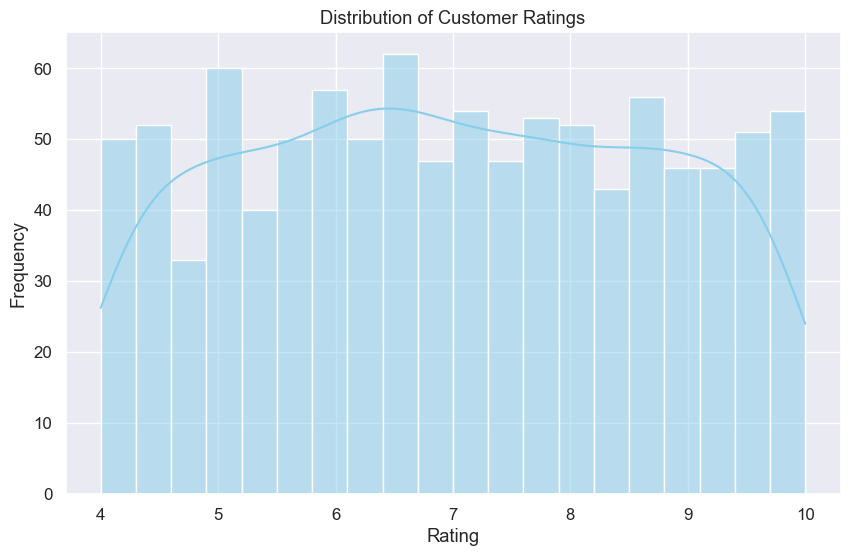

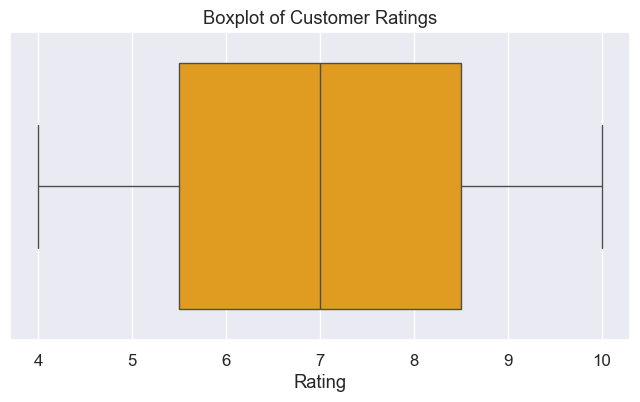


Skewness of Ratings:
0.009592348980681047

Total Sales by Branch:
Branch
A    106971.5325
B    106837.7100
C    110568.7065
Name: Total, dtype: float64


C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=branch_sales.index,


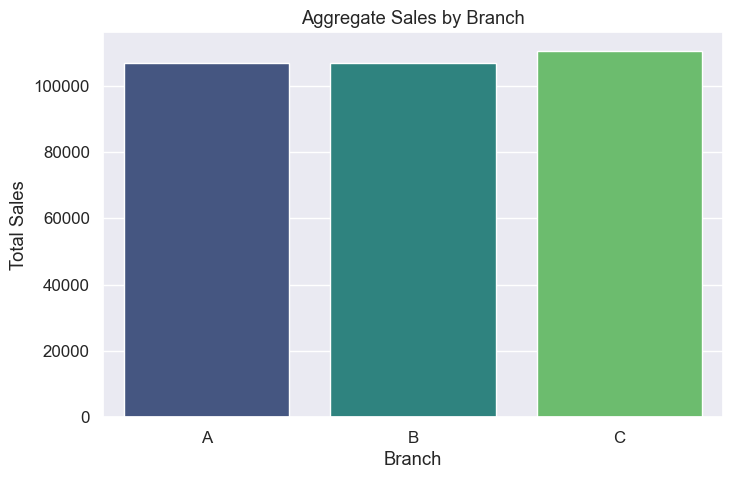

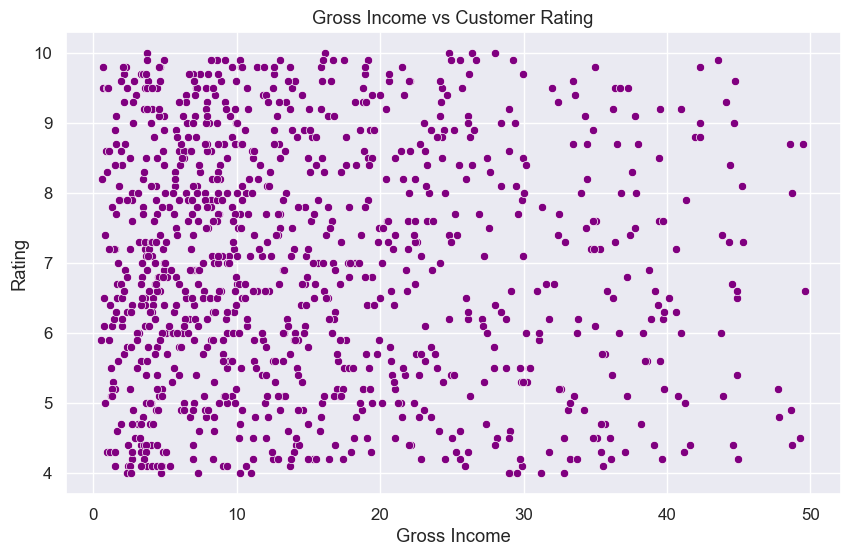


Correlation between Gross Income and Rating:
-0.0385905013394941


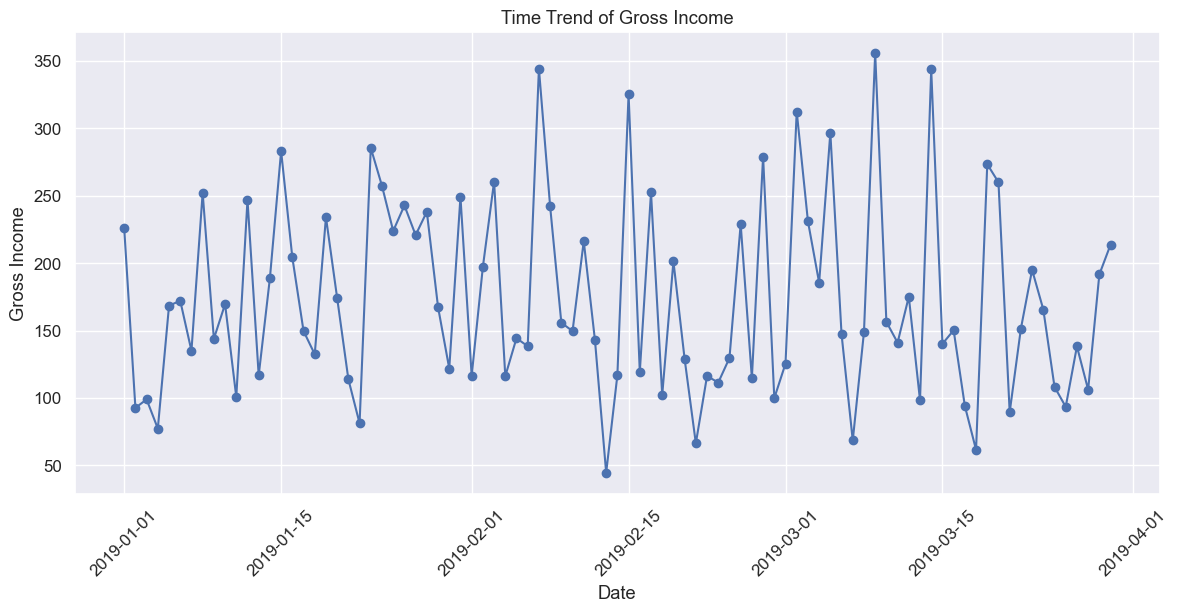


Duplicate Rows:
3

Dataset Shape After Removing Duplicates:
(1000, 20)

Missing Values Before Treatment:
Invoice ID                  0
Branch                      0
City                        0
Customer type              79
Gender                      0
Product line               43
Unit price                  6
Quantity                   19
Tax 5%                      0
Total                       0
Date                        0
Time                        0
Payment                     0
cogs                        0
gross margin percentage     0
gross income                0
Rating                      0
Month                       0
Day                         0
Hour                        0
dtype: int64

Missing Values After Treatment:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%          

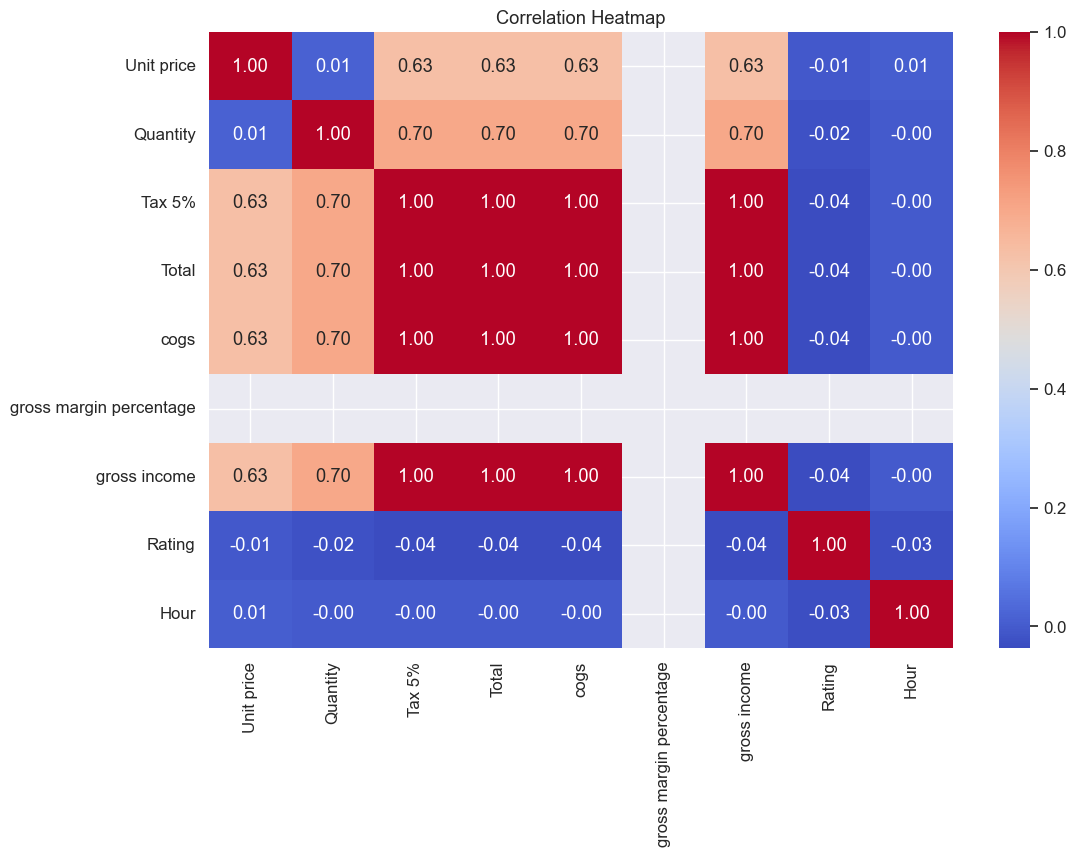

C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:266: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product line',


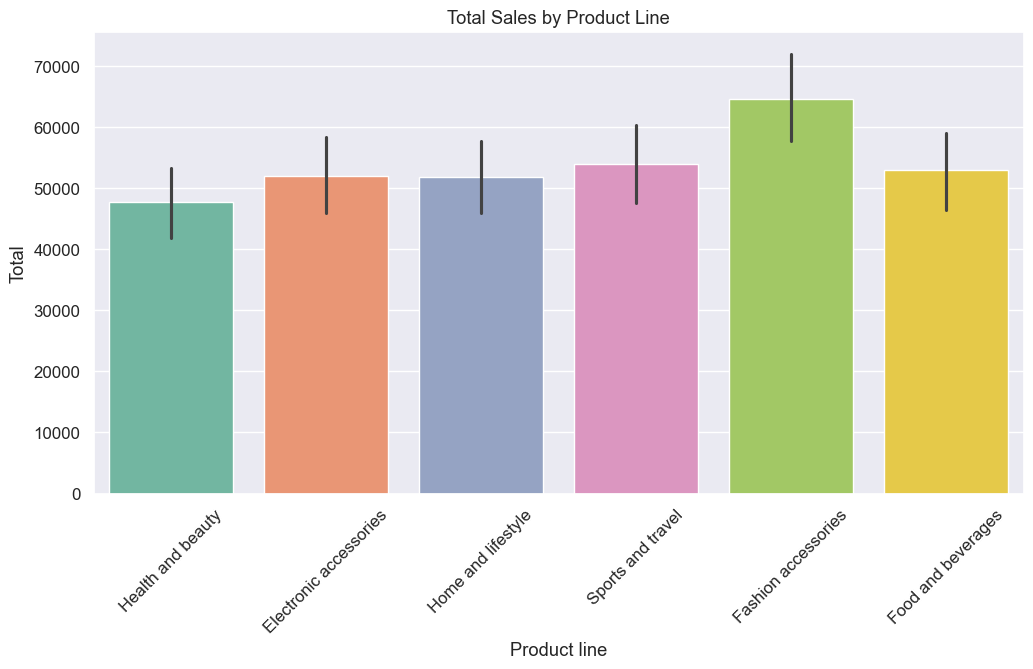

C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:284: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Payment',


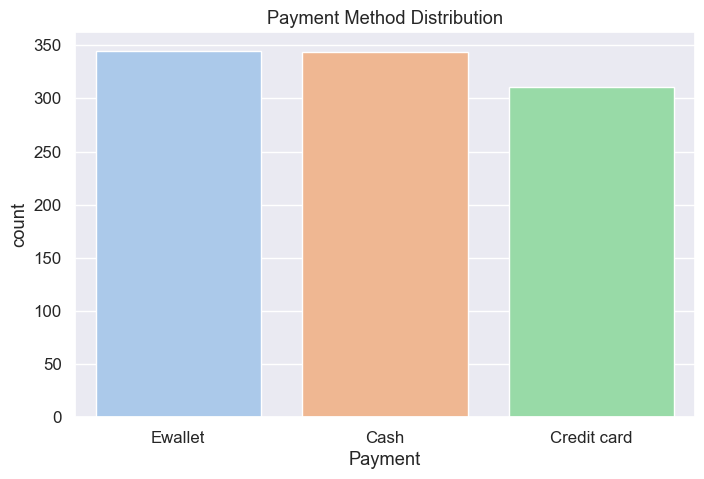

C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:298: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender',


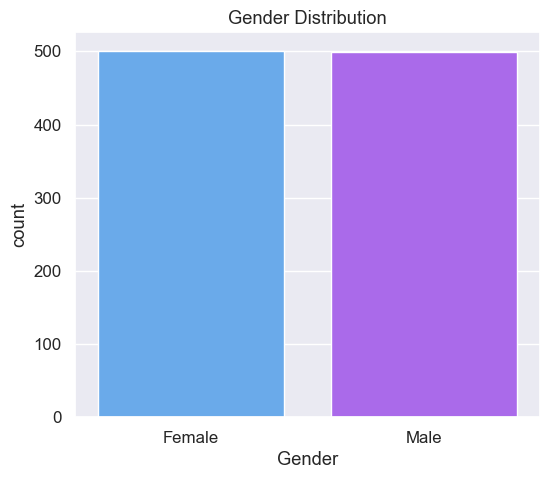

C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:312: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer type',


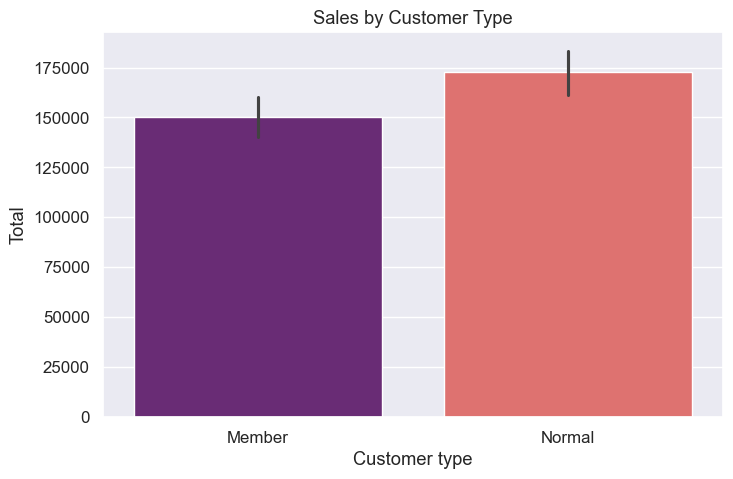

C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:328: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='City',


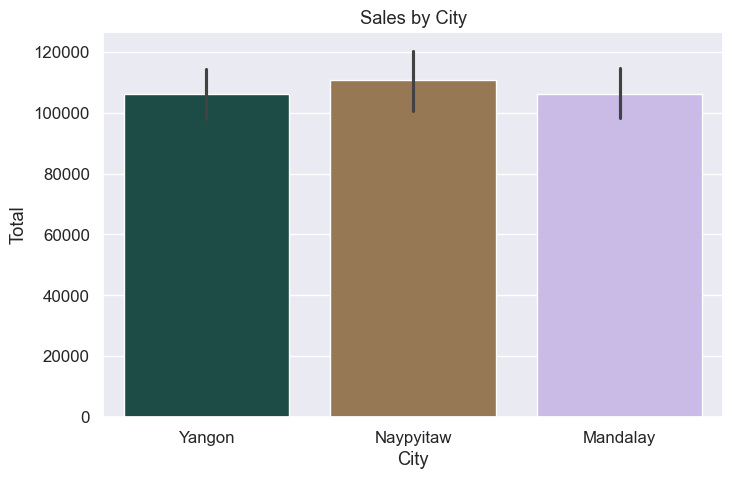

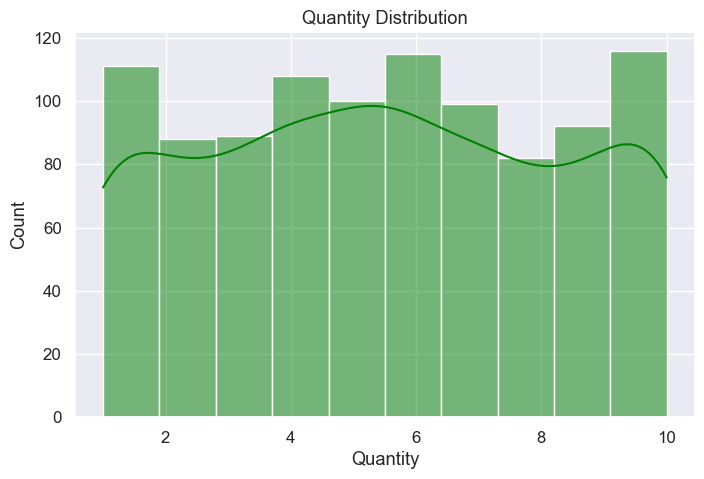

C:\Users\admin\AppData\Local\Temp\ipykernel_8324\2976968591.py:359: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product line',


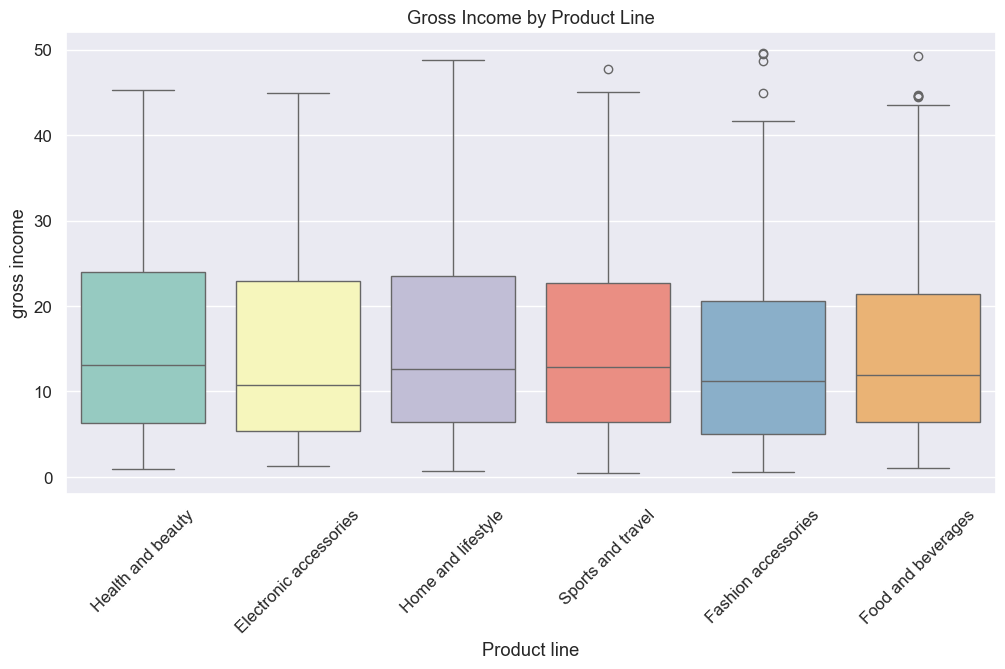


================ FINAL INSIGHTS ================

1. Customer ratings are nearly normally distributed.

2. Branch sales differ slightly across branches.

3. Gross income and customer ratings have weak correlation.

4. Gross income changes over time with fluctuations.

5. Dataset contains very few duplicate or missing values.

6. Strong positive correlation exists between:
   - Total and Gross Income
   - Quantity and Total Sales

7. Different product lines contribute differently to revenue.



In [4]:
# =========================================================
# Exploratory Data Analysis (EDA) With Python and Pandas
# Supermarket Sales Dataset
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style Settings
plt.style.use('ggplot')
sns.set(font_scale=1.1)

# =========================================================
# LOAD DATASET
# =========================================================

# Load dataset
df = pd.read_csv('supermarket_sales.csv')

# =========================================================
# BASIC DATA EXPLORATION
# =========================================================

print("First 5 Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# DATA PREPROCESSING
# =========================================================

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert Time column to datetime
df['Time'] = pd.to_datetime(df['Time'])

# Create additional useful columns
df['Month'] = df['Date'].dt.month_name()

df['Day'] = df['Date'].dt.day_name()

df['Hour'] = df['Time'].dt.hour

# =========================================================
# TASK 1: INITIAL DATA EXPLORATION
# =========================================================

print("\nUnique Cities:")
print(df['City'].unique())

print("\nUnique Branches:")
print(df['Branch'].unique())

print("\nCustomer Types:")
print(df['Customer type'].value_counts())

print("\nGender Distribution:")
print(df['Gender'].value_counts())

print("\nPayment Methods:")
print(df['Payment'].value_counts())

print("\nProduct Lines:")
print(df['Product line'].value_counts())

# =========================================================
# TASK 2: UNIVARIATE ANALYSIS
# =========================================================

# ---------------------------------------------------------
# Question 1:
# What does the distribution of customer ratings look like?
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.histplot(df['Rating'],
             bins=20,
             kde=True,
             color='skyblue')

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

# Boxplot for ratings

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Rating'],
            color='orange')

plt.title('Boxplot of Customer Ratings')

plt.show()

# Skewness
print("\nSkewness of Ratings:")
print(df['Rating'].skew())

# ---------------------------------------------------------
# Question 2:
# Do aggregate sales numbers differ by branch?
# ---------------------------------------------------------

branch_sales = df.groupby('Branch')['Total'].sum()

print("\nTotal Sales by Branch:")
print(branch_sales)

plt.figure(figsize=(8,5))

sns.barplot(x=branch_sales.index,
            y=branch_sales.values,
            palette='viridis')

plt.title('Aggregate Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')

plt.show()

# =========================================================
# TASK 3: BIVARIATE ANALYSIS
# =========================================================

# ---------------------------------------------------------
# Question 3:
# Relationship between Gross Income and Ratings
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(x='gross income',
                y='Rating',
                data=df,
                color='purple')

plt.title('Gross Income vs Customer Rating')
plt.xlabel('Gross Income')
plt.ylabel('Rating')

plt.show()

# Correlation value
correlation = df['gross income'].corr(df['Rating'])

print("\nCorrelation between Gross Income and Rating:")
print(correlation)

# ---------------------------------------------------------
# Question 4:
# Time Trend in Gross Income
# ---------------------------------------------------------

gross_income_trend = df.groupby('Date')['gross income'].sum()

plt.figure(figsize=(14,6))

plt.plot(gross_income_trend.index,
         gross_income_trend.values,
         marker='o')

plt.title('Time Trend of Gross Income')
plt.xlabel('Date')
plt.ylabel('Gross Income')

plt.xticks(rotation=45)

plt.show()

# =========================================================
# TASK 4: DEALING WITH DUPLICATES
# =========================================================

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

# =========================================================
# TASK 4: DEALING WITH MISSING VALUES
# =========================================================

print("\nMissing Values Before Treatment:")
print(df.isnull().sum())

# Fill numerical missing values with mean
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Treatment:")
print(df.isnull().sum())

# =========================================================
# TASK 5: CORRELATION ANALYSIS
# =========================================================

# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

# Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

# =========================================================
# ADDITIONAL VISUALIZATIONS
# =========================================================

# ---------------------------------------------------------
# Sales by Product Line
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

sns.barplot(x='Product line',
            y='Total',
            data=df,
            estimator=sum,
            palette='Set2')

plt.xticks(rotation=45)

plt.title('Total Sales by Product Line')

plt.show()

# ---------------------------------------------------------
# Payment Method Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(x='Payment',
              data=df,
              palette='pastel')

plt.title('Payment Method Distribution')

plt.show()

# ---------------------------------------------------------
# Gender Distribution
# ---------------------------------------------------------

plt.figure(figsize=(6,5))

sns.countplot(x='Gender',
              data=df,
              palette='cool')

plt.title('Gender Distribution')

plt.show()

# ---------------------------------------------------------
# Sales by Customer Type
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(x='Customer type',
            y='Total',
            data=df,
            estimator=sum,
            palette='magma')

plt.title('Sales by Customer Type')

plt.show()

# ---------------------------------------------------------
# Sales by City
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(x='City',
            y='Total',
            data=df,
            estimator=sum,
            palette='cubehelix')

plt.title('Sales by City')

plt.show()

# ---------------------------------------------------------
# Quantity Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df['Quantity'],
             bins=10,
             kde=True,
             color='green')

plt.title('Quantity Distribution')

plt.show()

# ---------------------------------------------------------
# Gross Income by Product Line
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

sns.boxplot(x='Product line',
            y='gross income',
            data=df,
            palette='Set3')

plt.xticks(rotation=45)

plt.title('Gross Income by Product Line')

plt.show()

# =========================================================
# FINAL INSIGHTS
# =========================================================

print("\n================ FINAL INSIGHTS ================")

print("""
1. Customer ratings are nearly normally distributed.

2. Branch sales differ slightly across branches.

3. Gross income and customer ratings have weak correlation.

4. Gross income changes over time with fluctuations.

5. Dataset contains very few duplicate or missing values.

6. Strong positive correlation exists between:
   - Total and Gross Income
   - Quantity and Total Sales

7. Different product lines contribute differently to revenue.
""")